
features
features.0
features.0.0
features.0.1
features.0.2
features.1
features.1.block
features.1.block.0
features.1.block.0.0
features.1.block.0.1
features.1.block.0.2
features.1.block.1
features.1.block.1.avgpool
features.1.block.1.fc1
features.1.block.1.fc2
features.1.block.1.activation
features.1.block.1.scale_activation
features.1.block.2
features.1.block.2.0
features.1.block.2.1
features.2
features.2.block
features.2.block.0
features.2.block.0.0
features.2.block.0.1
features.2.block.0.2
features.2.block.1
features.2.block.1.0
features.2.block.1.1
features.2.block.1.2
features.2.block.2
features.2.block.2.0
features.2.block.2.1
features.3
features.3.block
features.3.block.0
features.3.block.0.0
features.3.block.0.1
features.3.block.0.2
features.3.block.1
features.3.block.1.0
features.3.block.1.1
features.3.block.1.2
features.3.block.2
features.3.block.2.0
features.3.block.2.1
features.4
features.4.block
features.4.block.0
features.4.block.0.0
features.4.block.0.1
features.4.block

Text(0.5, 1.0, 'Validation Average Loss')

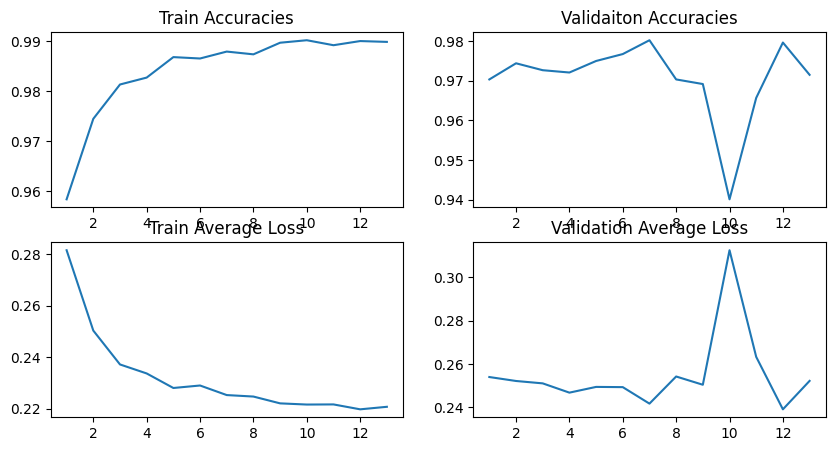

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torchvision import transforms
from torchvision import models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.RandomRotation(10),
                                transforms.RandomHorizontalFlip(p=0.3),
                                transforms.ColorJitter(brightness=0.1,
                                                       contrast=0.1,
                                                       saturation=0.1,
                                                       hue=0.10),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

val_transform = transforms.Compose([transforms.Resize((224,224)),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

train_path = Path("/content/train")
val_path = Path("/content/valid")
test_path = Path("/content/test")

train_data = ImageFolder(train_path, transform=train_transform)
val_data = ImageFolder(val_path, transform=val_transform)
test_data = ImageFolder(test_path,transform=val_transform)

train_loader = DataLoader(train_data, shuffle=True, batch_size=16)
val_loader = DataLoader(val_data, shuffle=False, batch_size=16)
test_loader = DataLoader(test_data, shuffle=False, batch_size=16)

model = models.mobilenet_v3_small(weights = models.MobileNet_V3_Small_Weights.DEFAULT).to(device)

for param in model.parameters():
  param.requires_grad = False

in_features = model.classifier[0].in_features

model.classifier = nn.Sequential(nn.Linear(in_features, 512),
                                 nn.ReLU(),
                                 nn.Dropout(p=0.5),

                                 nn.Linear(512, len(train_data.classes))).to(device)

features_list = ["features.10", "features.11", "features.12" ]

for name, module in model.named_modules():
  if name in features_list:
    for param in module.parameters():
      param.requires_grad = True

for name , module in model.named_modules():
  print (name)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad])

best_val = 0
counter = 0
patience = 5

epochs = 25

train_avg_losses = []
train_accuracies = []

val_avg_losses = []
val_accuracies = []

for epoch in range(epochs):
  model.train()

  train_loss = 0
  train_correct_preds = 0
  train_labels = 0

  for images,labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs= model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    preds = torch.argmax(outputs,dim=1)
    train_loss+=loss.item()

    train_correct_preds+=torch.sum(preds==labels).item()
    train_labels+=labels.shape[0]

  train_accuracy = train_correct_preds/train_labels
  train_average_loss = train_loss/len(train_loader)

  train_accuracies.append(train_accuracy)
  train_avg_losses.append(train_average_loss)

  model.eval()

  with torch.no_grad():

    val_loss = 0
    val_correct_pred = 0
    val_labels = 0

    for images, labels in val_loader:
      image,labels = images.to(device), labels.to(device)

      outputs = model(image)
      loss = criterion(outputs,labels)
      preds= torch.argmax(outputs,dim=1)

      val_correct_pred+=torch.sum(preds==labels).item()
      val_labels+=labels.size(0)

      val_loss+=loss.item()

    val_accuracy = val_correct_pred/val_labels
    val_avg_loss = val_loss/len(val_loader)

    val_accuracies.append(val_accuracy)
    val_avg_losses.append(val_avg_loss)

    print (f"Epochs {epoch+1}")

    print (f"Train Avergae Loss {train_average_loss}")
    print (f"Train_Accuracy {train_accuracy}")

    print (f"Validation Accuracy {val_accuracy}")
    print (f"Validation Average Loss {val_avg_loss}")

    if val_accuracy>best_val:
      best_val = val_accuracy
      counter = 0

      torch.save(model.state_dict(), "SoldierCivil.pt") # this is saving the best model

    else:
      counter+=1

      if counter>patience:
        print ("Early Stopping triggered")
        break

model.load_state_dict(torch.load("SoldierCivil.pt"))
model.eval()

with torch.no_grad():

  y_true = []
  y_pred = []

  for images, labels in test_loader:
    images,labels = images.to(device), labels.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

  print (f"Test Accuracy {accuracy_score(y_true,y_pred)}")
  print (f"Classification Score {classification_report(y_true,y_pred)}")
  print (f"Confusion Matrix {confusion_matrix(y_true,y_pred)}")

epochs_range_actual = range(1, len(train_accuracies) + 1)
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)

plt.plot(epochs_range_actual, train_accuracies)
plt.title("Train Accuracies")

plt.subplot(2,2,2)

plt.plot(epochs_range_actual, val_accuracies)
plt.title("Validaiton Accuracies")

plt.subplot(2,2,3)

plt.plot(epochs_range_actual, train_avg_losses)
plt.title("Train Average Loss")

plt.subplot(2,2,4)

plt.plot(epochs_range_actual, val_avg_losses)
plt.title("Validation Average Loss")